In [10]:
# Célula 1: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, f1_score, accuracy_score
)
from sklearn.model_selection import cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("🌳 RANDOM FOREST CLASSIFIER")
print("=" * 80)
print("\n💡 Por que Random Forest?")
print("   • Ensemble de árvores de decisão")
print("   • Robusto a outliers e features não-escaladas")
print("   • Feature importance nativa")
print("   • Geralmente melhor performance que baseline")

🌳 RANDOM FOREST CLASSIFIER

💡 Por que Random Forest?
   • Ensemble de árvores de decisão
   • Robusto a outliers e features não-escaladas
   • Feature importance nativa
   • Geralmente melhor performance que baseline


In [11]:
# Célula 2: Carregar Dados
print("\n" + "=" * 80)
print("📊 CARREGANDO DADOS")
print("=" * 80)

# Usar versão no_scale (melhor para tree-based models)
train_df = pd.read_csv('../data/final/no_scale_train_balanced.csv')
test_df = pd.read_csv('../data/final/no_scale_test.csv')

target_col = 'inadipl_90dias_ult2anos'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print(f"✅ Dados carregados:")
print(f"   Train: {X_train.shape}")
print(f"   Test:  {X_test.shape}")


📊 CARREGANDO DADOS
✅ Dados carregados:
   Train: (222762, 28)
   Test:  (29847, 28)


In [12]:
test_df['inadipl_90dias_ult2anos'].isna().sum()

np.int64(0)

In [13]:
# Célula 3: Treinar Random Forest (versão rápida)
print("\n" + "=" * 80)
print("🔄 TREINANDO RANDOM FOREST (Versão Rápida)")
print("=" * 80)

# Primeiro: versão rápida para testar
rf_quick = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n⏳ Treinando modelo rápido...")
rf_quick.fit(X_train, y_train)
print("✅ Modelo treinado!")

# Predições
y_pred_train = rf_quick.predict(X_train)
y_pred_test = rf_quick.predict(X_test)
y_pred_proba_test = rf_quick.predict_proba(X_test)[:, 1]

# Métricas rápidas
train_auc = roc_auc_score(y_train, rf_quick.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, y_pred_proba_test)
test_f1 = f1_score(y_test, y_pred_test)

print(f"\n📊 Performance Rápida:")
print(f"   Train AUC: {train_auc:.4f}")
print(f"   Test AUC:  {test_auc:.4f}")
print(f"   Test F1:   {test_f1:.4f}")


🔄 TREINANDO RANDOM FOREST (Versão Rápida)

⏳ Treinando modelo rápido...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.2s finished


✅ Modelo treinado!


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.7s finished



📊 Performance Rápida:
   Train AUC: 0.9909
   Test AUC:  0.8593
   Test F1:   0.4228



🔄 CROSS-VALIDATION (5-Fold)

⏳ Executando CV... (pode levar alguns minutos)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  2.1min remaining:  3.1min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.1min finished



📊 Resultados do Cross-Validation:
   Fold 1: 0.9532
   Fold 2: 0.9948
   Fold 3: 0.9943
   Fold 4: 0.9943
   Fold 5: 0.9941
   ─────────────────
   Média:  0.9861
   Std:    0.0165


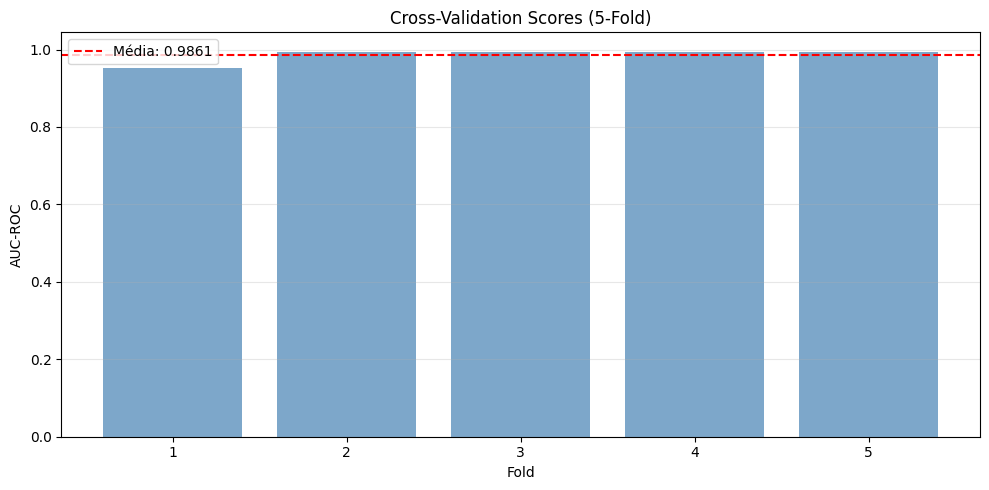

In [14]:
# Célula 4: Cross-Validation
print("\n" + "=" * 80)
print("🔄 CROSS-VALIDATION (5-Fold)")
print("=" * 80)

print("\n⏳ Executando CV... (pode levar alguns minutos)")

cv_scores = cross_val_score(
    rf_quick, X_train, y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print(f"\n📊 Resultados do Cross-Validation:")
print(f"   Fold 1: {cv_scores[0]:.4f}")
print(f"   Fold 2: {cv_scores[1]:.4f}")
print(f"   Fold 3: {cv_scores[2]:.4f}")
print(f"   Fold 4: {cv_scores[3]:.4f}")
print(f"   Fold 5: {cv_scores[4]:.4f}")
print(f"   ─────────────────")
print(f"   Média:  {cv_scores.mean():.4f}")
print(f"   Std:    {cv_scores.std():.4f}")

# Visualizar
plt.figure(figsize=(10, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Média: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title('Cross-Validation Scores (5-Fold)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Célula 5: Treinar Modelo Final (otimizado)
print("\n" + "=" * 80)
print("🌳 TREINANDO RANDOM FOREST FINAL (Otimizado)")
print("=" * 80)

# Modelo final com mais árvores e profundidade
rf_final = RandomForestClassifier(
    n_estimators=300,  # Mais árvores
    max_depth=20,      # Mais profundidade
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1,
    class_weight='balanced'
)

print("\n⏳ Treinando modelo final... (pode levar vários minutos)")
rf_final.fit(X_train, y_train)
print("✅ Modelo final treinado!")

# Predições
y_pred_train_final = rf_final.predict(X_train)
y_pred_test_final = rf_final.predict(X_test)
y_pred_proba_train_final = rf_final.predict_proba(X_train)[:, 1]
y_pred_proba_test_final = rf_final.predict_proba(X_test)[:, 1]


🌳 TREINANDO RANDOM FOREST FINAL (Otimizado)

⏳ Treinando modelo final... (pode levar vários minutos)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   12.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.6min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✅ Modelo final treinado!


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.3s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    2.1s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    3.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.4s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.6s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.5s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    2.7s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    4.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.4s f

In [16]:
# Célula 6: Avaliação Completa
print("\n" + "=" * 80)
print("📊 AVALIAÇÃO COMPLETA - MODELO FINAL")
print("=" * 80)

# Métricas train
train_accuracy = accuracy_score(y_train, y_pred_train_final)
train_f1 = f1_score(y_train, y_pred_train_final)
train_auc = roc_auc_score(y_train, y_pred_proba_train_final)

print(f"\n📈 TRAIN SET:")
print(f"   Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   F1-Score: {train_f1:.4f}")
print(f"   AUC-ROC:  {train_auc:.4f}")

# Métricas test
test_accuracy = accuracy_score(y_test, y_pred_test_final)
test_f1 = f1_score(y_test, y_pred_test_final)
test_auc = roc_auc_score(y_test, y_pred_proba_test_final)

print(f"\n📈 TEST SET:")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   F1-Score: {test_f1:.4f}")
print(f"   AUC-ROC:  {test_auc:.4f}")

print(f"\n📋 Classification Report (TEST):")
print(classification_report(y_test, y_pred_test_final,
                           target_names=['Bom Pagador', 'Inadimplente'],
                           digits=4))

# Comparar com baseline
lr_results = pd.read_csv('../reports/model_results.csv')
lr_auc = lr_results['test_auc'].values[0]

print(f"\n📊 COMPARAÇÃO COM BASELINE:")
print(f"   Logistic Regression AUC: {lr_auc:.4f}")
print(f"   Random Forest AUC:       {test_auc:.4f}")
print(f"   Melhoria:                +{(test_auc - lr_auc):.4f} ({((test_auc - lr_auc)/lr_auc)*100:+.2f}%)")

if test_auc > lr_auc:
    print(f"   ✅ Random Forest é MELHOR!")
else:
    print(f"   ⚠️ Logistic Regression ainda é melhor")


📊 AVALIAÇÃO COMPLETA - MODELO FINAL

📈 TRAIN SET:
   Accuracy: 0.9731 (97.31%)
   F1-Score: 0.9729
   AUC-ROC:  0.9973

📈 TEST SET:
   Accuracy: 0.9251 (92.51%)
   F1-Score: 0.4043
   AUC-ROC:  0.8563

📋 Classification Report (TEST):
              precision    recall  f1-score   support

 Bom Pagador     0.9558    0.9643    0.9600     27845
Inadimplente     0.4330    0.3791    0.4043      2002

    accuracy                         0.9251     29847
   macro avg     0.6944    0.6717    0.6821     29847
weighted avg     0.9207    0.9251    0.9227     29847


📊 COMPARAÇÃO COM BASELINE:
   Logistic Regression AUC: 0.7195
   Random Forest AUC:       0.8563
   Melhoria:                +0.1368 (+19.01%)
   ✅ Random Forest é MELHOR!



📊 VISUALIZAÇÕES


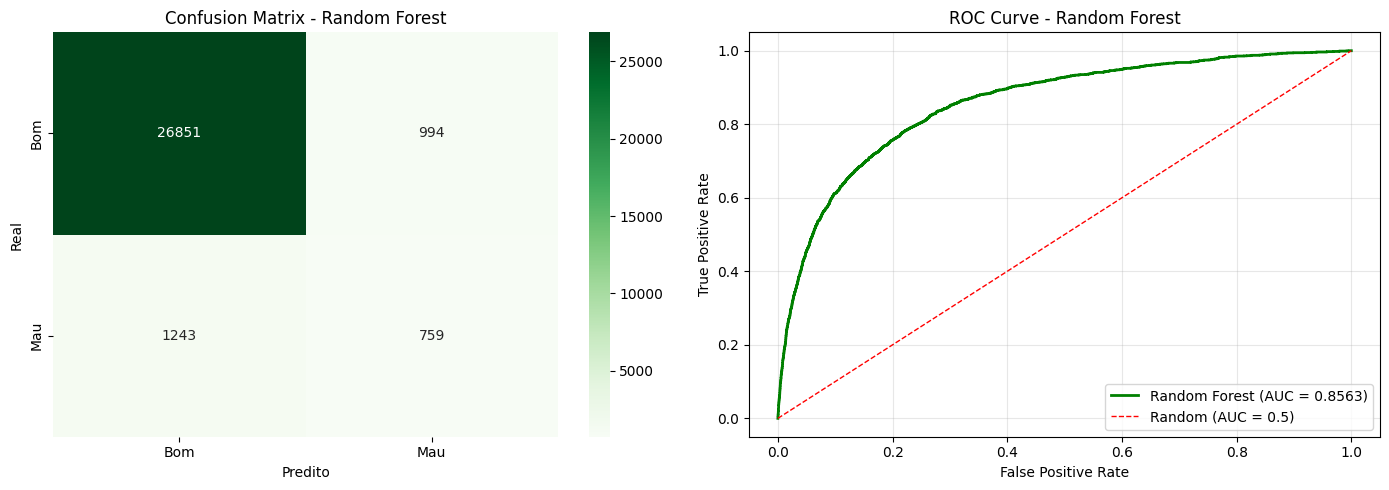


📊 Análise Detalhada:
   True Negatives:  26,851
   False Positives: 994
   False Negatives: 1,243 ⚠️
   True Positives:  759


In [17]:
# Célula 7: Confusion Matrix e ROC Curve
print("\n" + "=" * 80)
print("📊 VISUALIZAÇÕES")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
           xticklabels=['Bom', 'Mau'], yticklabels=['Bom', 'Mau'],
           ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_test_final)
axes[1].plot(fpr, tpr, 'g-', label=f'Random Forest (AUC = {test_auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'r--', label='Random (AUC = 0.5)', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Análise da Confusion Matrix
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Análise Detalhada:")
print(f"   True Negatives:  {tn:,}")
print(f"   False Positives: {fp:,}")
print(f"   False Negatives: {fn:,} ⚠️")
print(f"   True Positives:  {tp:,}")



🎯 FEATURE IMPORTANCE

🌟 Top 20 Features Mais Importantes:
                       feature  importance
     indice_severidade_atrasos    0.279421
        utilizacao_credito_bin    0.155987
   utilizacao_credito_quadrado    0.125244
          alta_utilizacao_flag    0.095803
            utilizacao_credito    0.072116
        utilizacao_media_linha    0.042620
     emprestimos_imobiliarioss    0.026451
                 score_interno    0.023292
     pressao_dependentes_renda    0.018501
                         idade    0.017536
        linhas_credito_abertas    0.016970
              renda_per_capita    0.016159
                idade_quadrado    0.012017
                  divida_ratio    0.010011
         interacao_idade_renda    0.009230
       interacao_divida_linhas    0.009213
comprometimento_renda_ajustado    0.008628
               flag_alto_risco    0.008414
            flag_possui_imovel    0.008374
              log_renda_mensal    0.008270


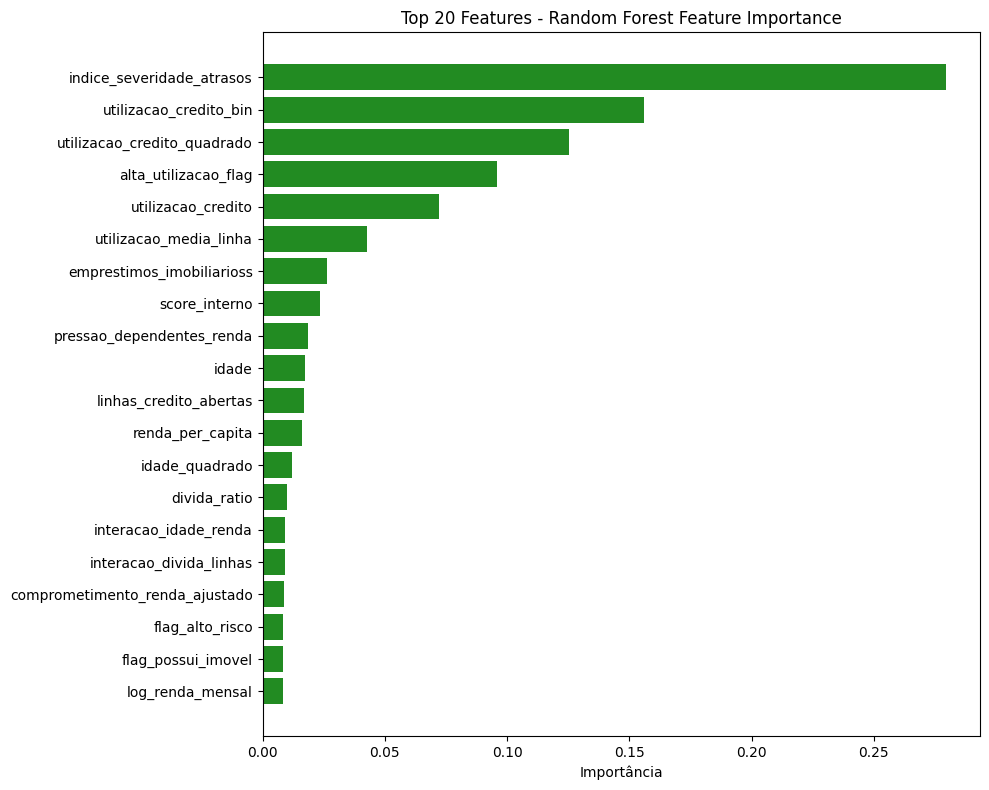


📊 Análise de Importância:
   Top 10 features: 85.7% da importância
   Top 20 features: 96.4% da importância
   12 features capturam 90% da importância


In [18]:
# Célula 8: Feature Importance
print("\n" + "=" * 80)
print("🎯 FEATURE IMPORTANCE")
print("=" * 80)

# Obter importâncias
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_final.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🌟 Top 20 Features Mais Importantes:")
print(feature_importance.head(20).to_string(index=False))

# Visualizar top 20
plt.figure(figsize=(10, 8))
top_20 = feature_importance.head(20)
plt.barh(top_20['feature'], top_20['importance'], color='forestgreen')
plt.xlabel('Importância')
plt.title('Top 20 Features - Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Importância acumulada
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()

# Quantas features para 90% da importância?
n_features_90 = (feature_importance['cumulative_importance'] <= 0.9).sum()
print(f"\n📊 Análise de Importância:")
print(f"   Top 10 features: {feature_importance.head(10)['importance'].sum()*100:.1f}% da importância")
print(f"   Top 20 features: {feature_importance.head(20)['importance'].sum()*100:.1f}% da importância")
print(f"   {n_features_90} features capturam 90% da importância")

In [20]:
# Célula 10: Salvar Modelo e Resultados
print("\n" + "=" * 80)
print("💾 SALVANDO MODELO E RESULTADOS")
print("=" * 80)

# Salvar modelo
model_path = '../models/random_forest.pkl'
joblib.dump(rf_final, model_path)
print(f"✅ Modelo salvo: {model_path}")

# Atualizar arquivo de resultados
new_results = {
    'model_name': 'Random Forest',
    'train_accuracy': train_accuracy,
    'train_f1': train_f1,
    'train_auc': train_auc,
    'test_accuracy': test_accuracy,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'n_features': X_train.shape[1],
    'n_estimators': rf_final.n_estimators,
    'max_depth': rf_final.max_depth
}

# Adicionar aos resultados existentes
results_df = pd.read_csv('../reports/model_results.csv')
results_df = pd.concat([results_df, pd.DataFrame([new_results])], ignore_index=True)
results_df.to_csv('../reports/model_results.csv', index=False)
print(f"✅ Resultados atualizados")

# Salvar feature importance
feature_importance.to_csv('../reports/rf_feature_importance.csv', index=False)
print(f"✅ Feature importance salvo")


💾 SALVANDO MODELO E RESULTADOS
✅ Modelo salvo: ../models/random_forest.pkl
✅ Resultados atualizados
✅ Feature importance salvo


In [21]:
# Célula 11: Resumo Final
print("\n" + "=" * 80)
print("🎉 RANDOM FOREST COMPLETO!")
print("=" * 80)

print(f"\n📊 PERFORMANCE FINAL:")
print(f"   Test AUC:      {test_auc:.4f}")
print(f"   Test F1:       {test_f1:.4f}")
print(f"   Test Accuracy: {test_accuracy:.4f}")

print(f"\n🔍 OVERFITTING:")
print(f"   Diferença AUC: {train_auc - test_auc:.4f}")
if (train_auc - test_auc) < 0.05:
    print(f"   ✅ Sem overfitting!")
else:
    print(f"   ⚠️ Possível overfitting")

print(f"\n🏆 RANKING DE MODELOS ATÉ AGORA:")
results_df_sorted = results_df.sort_values('test_auc', ascending=False)
print(results_df_sorted[['model_name', 'test_auc', 'test_f1']].to_string(index=False))

print(f"\n🎯 PRÓXIMO:")
print(f"   Dia 18: XGBoost/LightGBM")
print(f"   Objetivo: Superar AUC de {test_auc:.4f}")


🎉 RANDOM FOREST COMPLETO!

📊 PERFORMANCE FINAL:
   Test AUC:      0.8563
   Test F1:       0.4043
   Test Accuracy: 0.9251

🔍 OVERFITTING:
   Diferença AUC: 0.1410
   ⚠️ Possível overfitting

🏆 RANKING DE MODELOS ATÉ AGORA:
                    model_name  test_auc  test_f1
                 Random Forest  0.856266 0.404261
Logistic Regression (Baseline)  0.719505 0.035054

🎯 PRÓXIMO:
   Dia 18: XGBoost/LightGBM
   Objetivo: Superar AUC de 0.8563
